# 📊 Production KPI Analysis  
**Industrial Process Monitoring & Performance Evaluation**

---

## 🔷 Objective

The goal of this notebook is to analyze production and process data to generate **key performance indicators (KPIs)** that support decision-making in an industrial environment.

This analysis focuses on:
- Evaluating production performance
- Measuring quality through defect rates
- Understanding process behavior and variability

---

## 🏭 Business Context

In manufacturing environments, large volumes of process data are generated continuously. However, this data is often underutilized.

This notebook transforms raw production data into **actionable insights**, enabling:

- Monitoring of production efficiency  
- Early detection of quality issues  
- Identification of process variables impacting defects  

---

## 📁 Dataset Description

The dataset used in this project is based on the **AI4I Predictive Maintenance Dataset**, adapted to simulate a real production environment.

### Key characteristics:
- Each row represents a production observation  
- Includes process variables such as temperature, torque, and rotational speed  
- Contains failure indicators used as a proxy for defects  

---

## 🔧 Data Preparation Overview

To align the dataset with a production KPI framework, the following transformations will be applied:

- Creation of a **timestamp** to simulate production flow  
- Assignment of **production lines and shifts (A/B/C)**  
- Mapping of **machine failures to defect types**  
- Simulation of **production volume and defect counts**  

---

## 📊 KPIs to be Developed

This notebook will define and validate the following key metrics:

- **Throughput** → Units produced over time  
- **Defect Rate (%)** → Defective units relative to production  
- **Top Defects** → Most frequent failure categories  
- **Process Stability** → Variability of key process variables  

---

## 🚀 Next Steps

1. Load and explore the dataset  
2. Transform data into a production-ready structure  
3. Define KPI calculation logic  
4. Validate metrics through exploratory analysis  

---

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid ")

ValueError: style must be one of white, dark, whitegrid, darkgrid, ticks

In [33]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (10000, 14)

Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [36]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [35]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 🔎 Initial Observations

- The dataset contains process variables such as temperature, torque, and rotational speed.
- Failure indicators are available and will be used as a proxy for defects.
- No missing values are observed.
- Each row represents an individual production observation (no time dimension yet).

# 2. Data Transformation

In this section, the raw dataset is transformed into a structure that simulates a real industrial production environment. The goal is to enable KPI calculation and dashboard integration.

In [37]:
df = df.rename(columns={
    "Air temperature [K]": "air_temp",
    "Process temperature [K]": "process_temp",
    "Rotational speed [rpm]": "rpm",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "defect",
    "Type": "product_type"
})

In [38]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

def get_defect_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col
    return "No Failure"

df["defect_type"] = df.apply(get_defect_type, axis=1)

In [40]:
df['defect_type'].value_counts()

defect_type
No Failure    9652
HDF            115
PWF             91
OSF             78
TWF             46
RNF             18
Name: count, dtype: int64

### Timestamp Creation

A synthetic timestamp is generated to simulate a continuous production process.

In [42]:
df["timestamp"] = pd.date_range(
    start="2024-01-01",
    periods=len(df),
    freq="h"
)

### Production Context

Production lines and shifts are added to simulate real operational conditions.

In [46]:
np.random.seed(42)

df["line"] = np.random.choice(
    ["Line 1", "Line 2"],
    size=len(df)
)

def assign_shift(hour):
    if 6 <= hour < 14:
        return "A"
    elif 14 <= hour < 22:
        return "B"
    else:
        return "C"

df["shift"] = df["timestamp"].dt.hour.apply(assign_shift)

###  Production Volume Simulation

Production volume is simulated to enable throughput and efficiency analysis.

In [47]:
df["units_produced"] = np.random.randint(80, 120, size=len(df))

### Defect Quantification

Defect counts are derived from failure events to quantify quality performance.

In [48]:
df["defects"] = df["defect"] * np.random.randint(1, 5, size=len(df))

### Final Dataset Structure

Selection of relevant variables for KPI analysis and dashboard integration.

In [50]:
df_final = df[[
    "timestamp",
    "line",
    "product_type",
    "shift",
    "units_produced",
    "defects",
    "defect_type",
    "air_temp",
    "process_temp",
    "rpm",
    "torque",
    "tool_wear"
]].copy()

df_final.head()

,timestamp,line,product_type,shift,units_produced,defects,defect_type,air_temp,process_temp,rpm,torque,tool_wear
0,2024-01-01 00:00:00,Line 1,M,C,119,0,No Failure,298.1,308.6,1551,42.8,0
1,2024-01-01 01:00:00,Line 2,L,C,86,0,No Failure,298.2,308.7,1408,46.3,3
2,2024-01-01 02:00:00,Line 1,L,C,111,0,No Failure,298.1,308.5,1498,49.4,5
3,2024-01-01 03:00:00,Line 1,L,C,98,0,No Failure,298.2,308.6,1433,39.5,7
4,2024-01-01 04:00:00,Line 1,L,C,85,0,No Failure,298.2,308.7,1408,40.0,9


In [52]:
df_final["defect_type"].value_counts()

defect_type
No Failure    9652
HDF            115
PWF             91
OSF             78
TWF             46
RNF             18
Name: count, dtype: int64

In [54]:
OUTPUT_PATH = "../data/processed/production_data.csv"

df_final.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset saved to {OUTPUT_PATH}")

Dataset saved to ../data/processed/production_data.csv


### Throughput Analysis

Throughput represents the number of units produced over time and is a key indicator of production efficiency.

In [55]:
throughput = (
    df
    .set_index("timestamp")
    .resample("D")["units_produced"]
    .sum()
)

throughput.head()

timestamp
2024-01-01    2316
2024-01-02    2344
2024-01-03    2222
2024-01-04    2423
2024-01-05    2459
Freq: D, Name: units_produced, dtype: int32

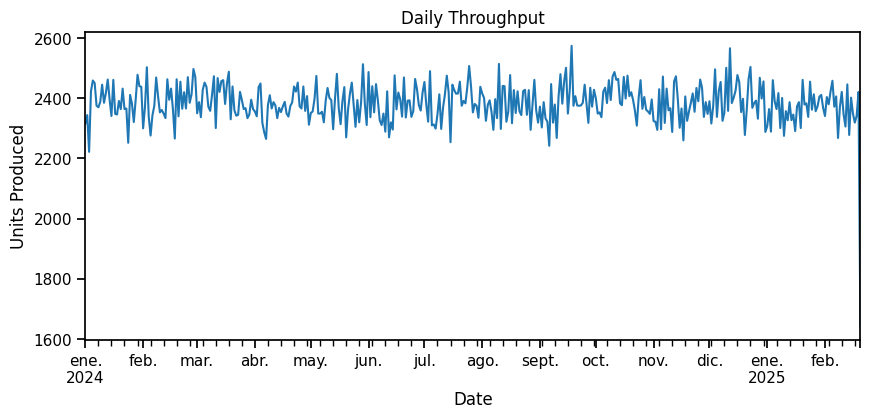

In [58]:
plt.figure(figsize=(10, 4))
throughput.plot()
plt.title("Daily Throughput")
plt.ylabel("Units Produced")
plt.xlabel("Date")
plt.show()

### Defect Rate

Defect rate measures the proportion of defective units relative to total production.

In [59]:
total_units = df["units_produced"].sum()
total_defects = df["defects"].sum()

defect_rate = total_defects / total_units

print(f"Defect Rate: {defect_rate:.2%}")

Defect Rate: 0.09%


In [60]:
defect_rate_time = (
    df
    .set_index("timestamp")
    .resample("D")
    .apply(lambda x: x["defects"].sum() / x["units_produced"].sum())
)

defect_rate_time.head()

timestamp
2024-01-01    0.000000
2024-01-02    0.000000
2024-01-03    0.001350
2024-01-04    0.001651
2024-01-05    0.000000
Freq: D, dtype: float64

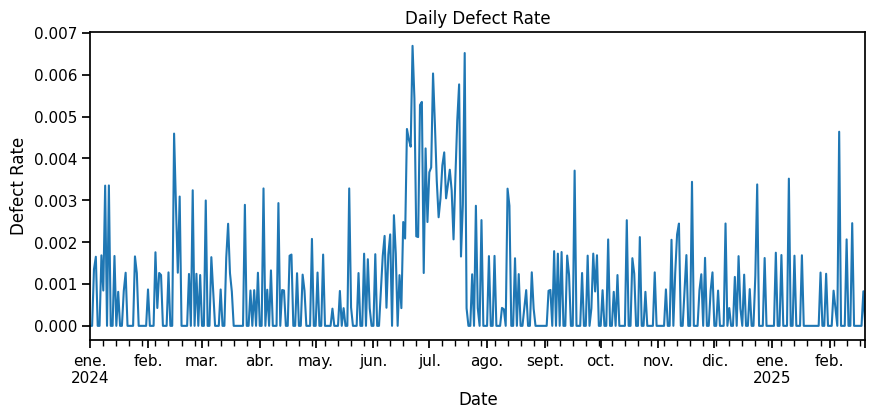

In [62]:
plt.figure(figsize=(10, 4))
defect_rate_time.plot()
plt.title("Daily Defect Rate")
plt.ylabel("Defect Rate")
plt.xlabel("Date")
plt.show()

### Top Defects

Identification of the most frequent defect types supports root cause analysis and prioritization.

In [63]:
top_defects = (
    df[df["defect_type"] != "No Failure"]
    .groupby("defect_type")["defects"]
    .sum()
    .sort_values(ascending=False)
)

top_defects

defect_type
HDF    282
PWF    243
OSF    194
TWF    124
RNF      0
Name: defects, dtype: int64

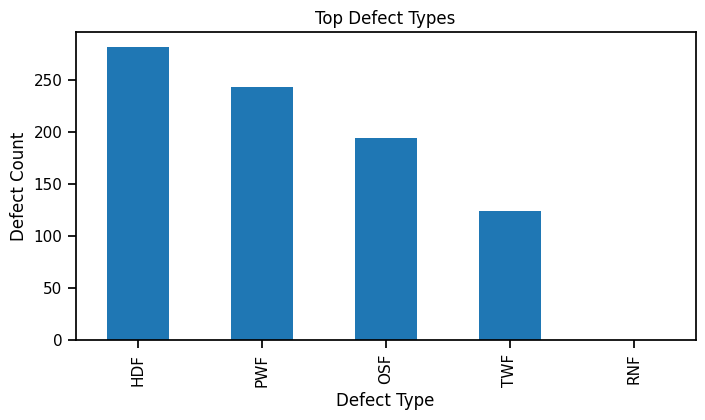

In [64]:
plt.figure(figsize=(8, 4))
top_defects.plot(kind="bar")
plt.title("Top Defect Types")
plt.ylabel("Defect Count")
plt.xlabel("Defect Type")
plt.show()

### Key Observations

- Throughput shows variability over time, indicating potential operational fluctuations.
- Defect rate provides a clear measure of quality performance and should be monitored continuously.
- Certain defect types dominate, suggesting opportunities for targeted process improvement.